### CONFIGURATION: Imports, datasets loading, etc.

##### Loaded MNISTs datasets are already proceessed: 4 bit binarization, 16x16, and split for: train/val/test

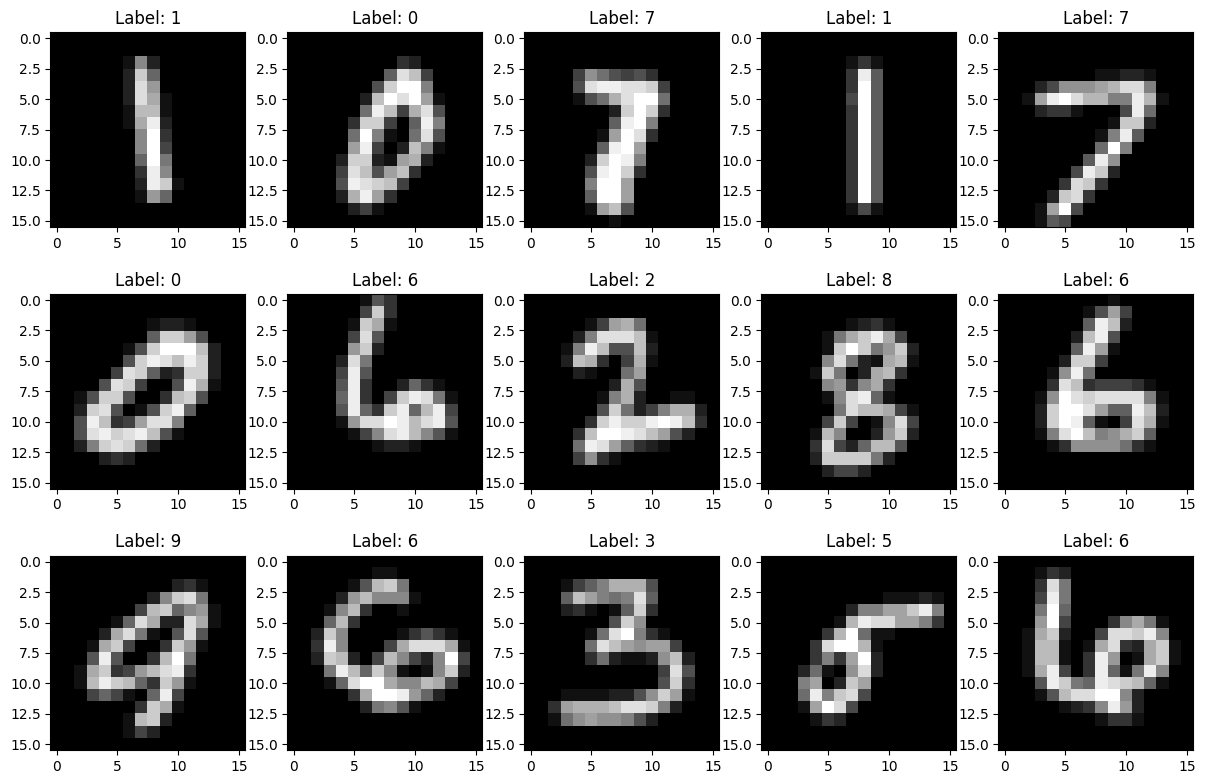

In [1]:
import joblib
import numpy as np
from experiments.QNN_integration.datasets.dataset_structure import DatasetSplit, DataBlock, DataSet
from pathlib import Path

seed = 71
rng = np.random.default_rng(seed)

mnist_digits_stratified_path = Path().absolute().parent / "QNN_integration" / "datasets" / ".MNIST_Digits_5_subsets_train_val_test_16x16.joblib"
mnist_digits_stratified = joblib.load(mnist_digits_stratified_path)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 5, figsize=(12, 8))

axes = axes.flatten()
for ax in axes:
	i = rng.integers(0, len(mnist_digits_stratified.subsets[0].train.X))
	ax.imshow(mnist_digits_stratified.subsets[0].train.X[i], cmap=plt.cm.gray)
	ax.set_title("Label: " + str(mnist_digits_stratified.subsets[0].train.y[i]))

plt.tight_layout()
plt.show()

In [2]:
from datetime import datetime

REPORT_WIDTH = 118
EPOCH_COLUMNS = [
	("Epoch", 9),
	("TrLoss", 8),
	("TrAcc", 8),
	("TrPrec", 8),
	("TrRec", 8),
	("TrF1", 8),
	("VaLoss", 8),
	("VaAcc", 8),
	("VaPrec", 8),
	("VaRec", 8),
	("VaF1", 8),
]


def _stringify_report_value(value):
	if isinstance(value, float):
		return f"{value:.4f}"
	if isinstance(value, (list, tuple)):
		return ", ".join(_stringify_report_value(item) for item in value)
	return str(value)



def _format_mapping(mapping):
	return ", ".join(
		f"{key}={_stringify_report_value(value)}"
		for key, value in mapping.items()
	)



def _wrap_report_line(prefix, value, width=REPORT_WIDTH):
	inner_width = width - 4
	text = f"{prefix}{_stringify_report_value(value)}"
	lines = []

	while len(text) > inner_width:
		split_at = text.rfind(" ", 0, inner_width + 1)
		if split_at <= len(prefix):
			split_at = inner_width
		lines.append(text[:split_at])
		text = (" " * len(prefix)) + text[split_at:].lstrip()

	lines.append(text)
	return [f"# {line.ljust(inner_width)} #" for line in lines]



def _render_report_box(title, rows, extra_lines=None, width=REPORT_WIDTH):
	inner_width = width - 4
	lines = [
		"#" * width,
		f"# {title.center(inner_width)} #",
		"#" * width,
	]

	for label, value in rows:
		lines.extend(_wrap_report_line(f"{label:<10}: ", value, width=width))

	for line in extra_lines or []:
		lines.extend(_wrap_report_line("", line, width=width))

	lines.append("#" * width)
	return "\n".join(lines)



def _make_table_border(fill='-'):
	return "+" + "+".join(fill * width for _, width in EPOCH_COLUMNS) + "+"



def _fit_table_value(value, width):
	text = _stringify_report_value(value)
	if len(text) > width:
		return text[:width]
	return text.rjust(width)



def print_experiment_report(title, dataset_name, classifier_name, subset_name, split_sizes, training_setup, model_setup=None):
	now = datetime.now()
	rows = [
		("DATE", now.strftime("%d-%m-%Y")),
		("TIME", now.strftime("%H:%M")),
		("DATASET", dataset_name),
		("CLASSIFIER", classifier_name),
		("SUBSET", subset_name),
		("SPLITS", _format_mapping(split_sizes)),
		("TRAINING", _format_mapping(training_setup)),
	]

	if model_setup:
		rows.append(("MODEL", _format_mapping(model_setup)))

	print(_render_report_box(title, rows))



def print_epoch_table_header():
	print(_make_table_border('-'))
	print("|" + "|".join(f"{name:^{width}}" for name, width in EPOCH_COLUMNS) + "|")
	print(_make_table_border('='))



def print_epoch_table_row(epoch, epochs, train_loss, train_metrics, val_loss, val_metrics):
	row_values = [
		f"{epoch:03d}/{epochs:03d}",
		f"{train_loss:.4f}",
		f"{train_metrics['accuracy']:.4f}",
		f"{train_metrics['precision']:.4f}",
		f"{train_metrics['recall']:.4f}",
		f"{train_metrics['f1']:.4f}",
		f"{val_loss:.4f}",
		f"{val_metrics['accuracy']:.4f}",
		f"{val_metrics['precision']:.4f}",
		f"{val_metrics['recall']:.4f}",
		f"{val_metrics['f1']:.4f}",
	]
	print("|" + "|".join(_fit_table_value(value, width) for value, (_, width) in zip(row_values, EPOCH_COLUMNS)) + "|")



def print_epoch_table_footer():
	print(_make_table_border('-'))



def print_metrics_report(title, metrics, matrix=None):
	rows = [
		(name.upper(), _stringify_report_value(value))
		for name, value in metrics.items()
	]

	extra_lines = []
	if matrix is not None:
		extra_lines.append("CONFUSION MATRIX:")
		extra_lines.extend(
			np.array2string(
				np.asarray(matrix),
				max_line_width=REPORT_WIDTH - 6,
			).splitlines()
		)

	print(_render_report_box(title, rows, extra_lines=extra_lines))



def print_summary_report(title, summary):
	rows = [
		("ACCURACY", f"{summary['accuracy_mean']:.4f} +/- {summary['accuracy_std']:.4f}"),
		("PRECISION", f"{summary['precision_mean']:.4f} +/- {summary['precision_std']:.4f}"),
		("RECALL", f"{summary['recall_mean']:.4f} +/- {summary['recall_std']:.4f}"),
		("F1", f"{summary['f1_mean']:.4f} +/- {summary['f1_std']:.4f}"),
	]
	print(_render_report_box(title, rows))


# CLASSICAL BASELINE TESTS

#### Classical PyTorch baseline architectures: Dense and CNN

In [ ]:
import torch
import torch.nn as nn
from torch.optim import Adam
import copy

from sklearn.metrics import (
	accuracy_score,
	precision_score,
	recall_score,
	f1_score,
	confusion_matrix
)

class DenseBaseline(nn.Module):
	def __init__(self, num_classes=10):
		super().__init__()
		self.flatten = nn.Flatten()
		self.classical_head_dense = nn.Linear(16 * 16, num_classes)

	def forward(self, x):
		x = self.flatten(x)
		x = self.classical_head_dense(x)
		return x
	
def numpy_images_to_torch(x_np: np.ndarray, device: str = "cpu") -> torch.Tensor:
	"""
	Konwersja obrazów uint8 [0, 255] -> float32 [0, 1].
	Obsługuje wejście o kształcie:
	- (N, 16, 16)
	- (16, 16) dla pojedynczej próbki
	"""
	x_np = np.asarray(x_np)

	if x_np.ndim == 2:
		x_np = np.expand_dims(x_np, axis=0)

	x_tensor = torch.tensor(x_np, dtype=torch.float32, device=device) / 255.0
	return x_tensor


def numpy_labels_to_torch(y_np: np.ndarray, device: str = "cpu") -> torch.Tensor:
	y_np = np.asarray(y_np)
	return torch.tensor(y_np, dtype=torch.long, device=device)


def compute_classification_metrics(y_true, y_pred):
	return {
		"accuracy": float(accuracy_score(y_true, y_pred)),
		"precision": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
		"recall": float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
		"f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
	}


def evaluate_model(model, split, criterion, device="cpu", batch_size=32):
	"""
	Ewaluacja modelu na dowolnym splicie: train / val / test.
	Zwraca:
	- średnią stratę
	- metryki klasyfikacyjne
	- y_true, y_pred
	"""
	model.eval()

	x_all = numpy_images_to_torch(split.X, device=device)
	y_all = numpy_labels_to_torch(split.y, device=device)

	all_losses = []
	all_preds = []
	all_true = []

	with torch.no_grad():
		for start_idx in range(0, len(x_all), batch_size):
			end_idx = start_idx + batch_size

			x_batch = x_all[start_idx:end_idx]
			y_batch = y_all[start_idx:end_idx]

			logits = model(x_batch)
			loss = criterion(logits, y_batch)

			preds = torch.argmax(logits, dim=1)

			all_losses.append(loss.item())
			all_preds.extend(preds.cpu().numpy().tolist())
			all_true.extend(y_batch.cpu().numpy().tolist())

	metrics = compute_classification_metrics(all_true, all_preds)

	return {
		"loss": float(np.mean(all_losses)) if len(all_losses) > 0 else 0.0,
		"accuracy": metrics["accuracy"],
		"precision": metrics["precision"],
		"recall": metrics["recall"],
		"f1": metrics["f1"],
		"y_true": all_true,
		"y_pred": all_preds,
	}


def train_one_block(
	data_block,
	num_classes=10,
	epochs=20,
	batch_size=32,
	lr=1e-3,
	device="cpu",
	verbose=True,
	report_context=None
):
	"""
	Trening pojedynczego DataBlock:
	- uczy na train
	- co epokę waliduje na val
	- na końcu testuje na test
	"""
	model = DenseBaseline(num_classes=num_classes).to(device)
	criterion = nn.CrossEntropyLoss()
	optimizer = Adam(model.parameters(), lr=lr)

	x_train = numpy_images_to_torch(data_block.train.X, device=device)
	y_train = numpy_labels_to_torch(data_block.train.y, device=device)

	history = {
		"train_loss": [],
		"train_accuracy": [],
		"train_precision": [],
		"train_recall": [],
		"train_f1": [],
		"val_loss": [],
		"val_accuracy": [],
		"val_precision": [],
		"val_recall": [],
		"val_f1": [],
	}

	best_val_f1 = -np.inf
	best_model_state = None

	for epoch in range(epochs):
		model.train()

		indices = torch.randperm(len(x_train), device=device)

		epoch_losses = []
		epoch_preds = []
		epoch_true = []

		for start_idx in range(0, len(indices), batch_size):
			batch_idx = indices[start_idx:start_idx + batch_size]

			x_batch = x_train[batch_idx]
			y_batch = y_train[batch_idx]

			logits = model(x_batch)
			loss = criterion(logits, y_batch)

			optimizer.zero_grad()
			loss.backward()
			optimizer.step()

			preds = torch.argmax(logits, dim=1)

			epoch_losses.append(loss.item())
			epoch_preds.extend(preds.detach().cpu().numpy().tolist())
			epoch_true.extend(y_batch.detach().cpu().numpy().tolist())

		train_metrics = compute_classification_metrics(epoch_true, epoch_preds)
		train_loss = float(np.mean(epoch_losses)) if len(epoch_losses) > 0 else 0.0

		val_results = evaluate_model(
			model=model,
			split=data_block.val,
			criterion=criterion,
			device=device,
			batch_size=batch_size
		)

		history["train_loss"].append(train_loss)
		history["train_accuracy"].append(train_metrics["accuracy"])
		history["train_precision"].append(train_metrics["precision"])
		history["train_recall"].append(train_metrics["recall"])
		history["train_f1"].append(train_metrics["f1"])

		history["val_loss"].append(val_results["loss"])
		history["val_accuracy"].append(val_results["accuracy"])
		history["val_precision"].append(val_results["precision"])
		history["val_recall"].append(val_results["recall"])
		history["val_f1"].append(val_results["f1"])

		if val_results["f1"] > best_val_f1:
			best_val_f1 = val_results["f1"]
			best_model_state = copy.deepcopy(model.state_dict())

		if verbose:
			if epoch == 0:
				if report_context is not None:
					print_experiment_report(**report_context)
				print_epoch_table_header()
			print_epoch_table_row(
				epoch=epoch + 1,
				epochs=epochs,
				train_loss=train_loss,
				train_metrics=train_metrics,
				val_loss=val_results["loss"],
				val_metrics=val_results
			)

	if verbose and epochs > 0:
		print_epoch_table_footer()

	if best_model_state is not None:
		model.load_state_dict(best_model_state)

	test_results = evaluate_model(
		model=model,
		split=data_block.test,
		criterion=criterion,
		device=device,
		batch_size=batch_size
	)

	test_cm = confusion_matrix(
		test_results["y_true"],
		test_results["y_pred"],
		labels=list(range(num_classes))
	)

	if verbose:
		print_metrics_report(
			title="TEST RESULTS",
			metrics={
				"loss": test_results["loss"],
				"accuracy": test_results["accuracy"],
				"precision": test_results["precision"],
				"recall": test_results["recall"],
				"f1": test_results["f1"],
			},
			matrix=test_cm
		)

	return {
		"model": model,
		"history": history,
		"test_metrics": {
			"loss": test_results["loss"],
			"accuracy": test_results["accuracy"],
			"precision": test_results["precision"],
			"recall": test_results["recall"],
			"f1": test_results["f1"],
		},
		"confusion_matrix": test_cm,
		"y_true": test_results["y_true"],
		"y_pred": test_results["y_pred"],
	}


def train_all_subsets(
	dataset,
	num_classes=10,
	epochs=20,
	batch_size=32,
	lr=1e-3,
	device="cpu",
	verbose=True
):
	"""
	Trening dla wszystkich 5 DataBlocków w dataset.subsets.
	Zwraca listę wyników dla każdego subsetu oraz agregację końcową.
	"""
	all_results = []

	for subset_idx, data_block in enumerate(dataset.subsets):
		report_context = {
			"title": "EXPERIMENTAL PROTOCOL REPORT",
			"dataset_name": "MNIST digits stratified",
			"classifier_name": "DenseBaseline",
			"subset_name": f"{subset_idx + 1}/{len(dataset.subsets)}",
			"split_sizes": {
				"train": len(data_block.train.X),
				"val": len(data_block.val.X),
				"test": len(data_block.test.X),
			},
			"training_setup": {
				"epochs": epochs,
				"batch_size": batch_size,
				"lr": lr,
				"device": device,
			},
			"model_setup": {
				"num_classes": num_classes,
			},
		}

		result = train_one_block(
			data_block=data_block,
			num_classes=num_classes,
			epochs=epochs,
			batch_size=batch_size,
			lr=lr,
			device=device,
			verbose=verbose,
			report_context=report_context
		)

		all_results.append(result)

	accuracies = [r["test_metrics"]["accuracy"] for r in all_results]
	precisions = [r["test_metrics"]["precision"] for r in all_results]
	recalls = [r["test_metrics"]["recall"] for r in all_results]
	f1s = [r["test_metrics"]["f1"] for r in all_results]

	summary = {
		"accuracy_mean": float(np.mean(accuracies)),
		"accuracy_std": float(np.std(accuracies)),
		"precision_mean": float(np.mean(precisions)),
		"precision_std": float(np.std(precisions)),
		"recall_mean": float(np.mean(recalls)),
		"recall_std": float(np.std(recalls)),
		"f1_mean": float(np.mean(f1s)),
		"f1_std": float(np.std(f1s)),
	}

	if verbose:
		print_summary_report("FINAL SUMMARY ACROSS SUBSETS", summary)

	return {
		"subset_results": all_results,
		"summary": summary
	}

results = train_all_subsets(
	dataset=mnist_digits_stratified,
	num_classes=10,
	epochs=10,
	batch_size=16,
	lr=1e-3,
	device="cpu",
	verbose=True
)


TRAINING SUBSET 1/5
Epoch 001/010 | train_loss=2.1004 | train_acc=0.4017 | train_prec=0.5561 | train_rec=0.4017 | train_f1=0.3921 | val_loss=1.8952 | val_acc=0.6580 | val_prec=0.7473 | val_rec=0.6580 | val_f1=0.6536
Epoch 002/010 | train_loss=1.7296 | train_acc=0.7709 | train_prec=0.7852 | train_rec=0.7709 | train_f1=0.7686 | val_loss=1.5917 | val_acc=0.7706 | val_prec=0.7918 | val_rec=0.7706 | val_f1=0.7661
Epoch 003/010 | train_loss=1.4573 | train_acc=0.8154 | train_prec=0.8302 | train_rec=0.8154 | train_f1=0.8123 | val_loss=1.3743 | val_acc=0.7879 | val_prec=0.8099 | val_rec=0.7879 | val_f1=0.7882
Epoch 004/010 | train_loss=1.2628 | train_acc=0.8306 | train_prec=0.8349 | train_rec=0.8306 | train_f1=0.8290 | val_loss=1.2134 | val_acc=0.7922 | val_prec=0.8082 | val_rec=0.7922 | val_f1=0.7926
Epoch 005/010 | train_loss=1.1161 | train_acc=0.8328 | train_prec=0.8389 | train_rec=0.8328 | train_f1=0.8315 | val_loss=1.0933 | val_acc=0.7965 | val_prec=0.8113 | val_rec=0.7965 | val_f1=0.7970

#### Baseline B: CNN

In [ ]:
import copy
import numpy as np

import torch
import torch.nn as nn
from torch.optim import Adam

from sklearn.metrics import (
	accuracy_score,
	precision_score,
	recall_score,
	f1_score,
	confusion_matrix
)

class SimpleCNNBaseline(nn.Module):
	def __init__(self, num_classes=10):
		super().__init__()
		self.features = nn.Sequential(
			nn.Conv2d(1, 16, kernel_size=3, padding=1),
			nn.ReLU(),
			nn.MaxPool2d(kernel_size=2),

			nn.Conv2d(16, 32, kernel_size=3, padding=1),
			nn.ReLU(),
			nn.MaxPool2d(kernel_size=2)
		)

		self.classifier = nn.Sequential(
			nn.Flatten(),
			nn.Linear(32 * 4 * 4, 64),
			nn.ReLU(),
			nn.Linear(64, num_classes)
		)

	def forward(self, x):
		x = self.features(x)
		x = self.classifier(x)
		return x


def numpy_images_to_torch_cnn(x_np: np.ndarray, device: str = "cpu") -> torch.Tensor:
	"""
	Konwersja obrazów uint8 [0, 255] -> float32 [0, 1]
	oraz dodanie wymiaru kanału dla CNN.

	Wejście:
	- (N, 16, 16)
	- (16, 16)

	Wyjście:
	- (N, 1, 16, 16)
	"""
	x_np = np.asarray(x_np)

	if x_np.ndim == 2:
		x_np = np.expand_dims(x_np, axis=0)

	x_tensor = torch.tensor(x_np, dtype=torch.float32, device=device) / 255.0
	x_tensor = x_tensor.unsqueeze(1)
	return x_tensor


def numpy_labels_to_torch(y_np: np.ndarray, device: str = "cpu") -> torch.Tensor:
	y_np = np.asarray(y_np)
	return torch.tensor(y_np, dtype=torch.long, device=device)


def compute_classification_metrics(y_true, y_pred):
	return {
		"accuracy": float(accuracy_score(y_true, y_pred)),
		"precision": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
		"recall": float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
		"f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
	}


def evaluate_cnn_model(model, split, criterion, device="cpu", batch_size=32):
	model.eval()

	x_all = numpy_images_to_torch_cnn(split.X, device=device)
	y_all = numpy_labels_to_torch(split.y, device=device)

	all_losses = []
	all_preds = []
	all_true = []

	with torch.no_grad():
		for start_idx in range(0, len(x_all), batch_size):
			end_idx = start_idx + batch_size

			x_batch = x_all[start_idx:end_idx]
			y_batch = y_all[start_idx:end_idx]

			logits = model(x_batch)
			loss = criterion(logits, y_batch)

			preds = torch.argmax(logits, dim=1)

			all_losses.append(loss.item())
			all_preds.extend(preds.cpu().numpy().tolist())
			all_true.extend(y_batch.cpu().numpy().tolist())

	metrics = compute_classification_metrics(all_true, all_preds)

	return {
		"loss": float(np.mean(all_losses)) if len(all_losses) > 0 else 0.0,
		"accuracy": metrics["accuracy"],
		"precision": metrics["precision"],
		"recall": metrics["recall"],
		"f1": metrics["f1"],
		"y_true": all_true,
		"y_pred": all_preds,
	}


def train_one_block_cnn(
	data_block,
	num_classes=10,
	epochs=20,
	batch_size=32,
	lr=1e-3,
	device="cpu",
	verbose=True,
	report_context=None
):
	model = SimpleCNNBaseline(num_classes=num_classes).to(device)
	criterion = nn.CrossEntropyLoss()
	optimizer = Adam(model.parameters(), lr=lr)

	x_train = numpy_images_to_torch_cnn(data_block.train.X, device=device)
	y_train = numpy_labels_to_torch(data_block.train.y, device=device)

	history = {
		"train_loss": [],
		"train_accuracy": [],
		"train_precision": [],
		"train_recall": [],
		"train_f1": [],
		"val_loss": [],
		"val_accuracy": [],
		"val_precision": [],
		"val_recall": [],
		"val_f1": [],
	}

	best_val_f1 = -np.inf
	best_model_state = None

	for epoch in range(epochs):
		model.train()

		indices = torch.randperm(len(x_train), device=device)

		epoch_losses = []
		epoch_preds = []
		epoch_true = []

		for start_idx in range(0, len(indices), batch_size):
			batch_idx = indices[start_idx:start_idx + batch_size]

			x_batch = x_train[batch_idx]
			y_batch = y_train[batch_idx]

			logits = model(x_batch)
			loss = criterion(logits, y_batch)

			optimizer.zero_grad()
			loss.backward()
			optimizer.step()

			preds = torch.argmax(logits, dim=1)

			epoch_losses.append(loss.item())
			epoch_preds.extend(preds.detach().cpu().numpy().tolist())
			epoch_true.extend(y_batch.detach().cpu().numpy().tolist())

		train_metrics = compute_classification_metrics(epoch_true, epoch_preds)
		train_loss = float(np.mean(epoch_losses)) if len(epoch_losses) > 0 else 0.0

		val_results = evaluate_cnn_model(
			model=model,
			split=data_block.val,
			criterion=criterion,
			device=device,
			batch_size=batch_size
		)

		history["train_loss"].append(train_loss)
		history["train_accuracy"].append(train_metrics["accuracy"])
		history["train_precision"].append(train_metrics["precision"])
		history["train_recall"].append(train_metrics["recall"])
		history["train_f1"].append(train_metrics["f1"])

		history["val_loss"].append(val_results["loss"])
		history["val_accuracy"].append(val_results["accuracy"])
		history["val_precision"].append(val_results["precision"])
		history["val_recall"].append(val_results["recall"])
		history["val_f1"].append(val_results["f1"])

		if val_results["f1"] > best_val_f1:
			best_val_f1 = val_results["f1"]
			best_model_state = copy.deepcopy(model.state_dict())

		if verbose:
			if epoch == 0:
				if report_context is not None:
					print_experiment_report(**report_context)
				print_epoch_table_header()
			print_epoch_table_row(
				epoch=epoch + 1,
				epochs=epochs,
				train_loss=train_loss,
				train_metrics=train_metrics,
				val_loss=val_results["loss"],
				val_metrics=val_results
			)

	if verbose and epochs > 0:
		print_epoch_table_footer()

	if best_model_state is not None:
		model.load_state_dict(best_model_state)

	test_results = evaluate_cnn_model(
		model=model,
		split=data_block.test,
		criterion=criterion,
		device=device,
		batch_size=batch_size
	)

	test_cm = confusion_matrix(
		test_results["y_true"],
		test_results["y_pred"],
		labels=list(range(num_classes))
	)

	if verbose:
		print_metrics_report(
			title="TEST RESULTS",
			metrics={
				"loss": test_results["loss"],
				"accuracy": test_results["accuracy"],
				"precision": test_results["precision"],
				"recall": test_results["recall"],
				"f1": test_results["f1"],
			},
			matrix=test_cm
		)

	return {
		"model": model,
		"history": history,
		"test_metrics": {
			"loss": test_results["loss"],
			"accuracy": test_results["accuracy"],
			"precision": test_results["precision"],
			"recall": test_results["recall"],
			"f1": test_results["f1"],
		},
		"confusion_matrix": test_cm,
		"y_true": test_results["y_true"],
		"y_pred": test_results["y_pred"],
	}


def train_all_subsets_cnn(
	dataset,
	num_classes=10,
	epochs=20,
	batch_size=32,
	lr=1e-3,
	device="cpu",
	verbose=True
):
	all_results = []

	for subset_idx, data_block in enumerate(dataset.subsets):
		report_context = {
			"title": "EXPERIMENTAL PROTOCOL REPORT",
			"dataset_name": "MNIST digits stratified",
			"classifier_name": "SimpleCNNBaseline",
			"subset_name": f"{subset_idx + 1}/{len(dataset.subsets)}",
			"split_sizes": {
				"train": len(data_block.train.X),
				"val": len(data_block.val.X),
				"test": len(data_block.test.X),
			},
			"training_setup": {
				"epochs": epochs,
				"batch_size": batch_size,
				"lr": lr,
				"device": device,
			},
			"model_setup": {
				"num_classes": num_classes,
			},
		}

		result = train_one_block_cnn(
			data_block=data_block,
			num_classes=num_classes,
			epochs=epochs,
			batch_size=batch_size,
			lr=lr,
			device=device,
			verbose=verbose,
			report_context=report_context
		)

		all_results.append(result)

	accuracies = [r["test_metrics"]["accuracy"] for r in all_results]
	precisions = [r["test_metrics"]["precision"] for r in all_results]
	recalls = [r["test_metrics"]["recall"] for r in all_results]
	f1s = [r["test_metrics"]["f1"] for r in all_results]

	summary = {
		"accuracy_mean": float(np.mean(accuracies)),
		"accuracy_std": float(np.std(accuracies)),
		"precision_mean": float(np.mean(precisions)),
		"precision_std": float(np.std(precisions)),
		"recall_mean": float(np.mean(recalls)),
		"recall_std": float(np.std(recalls)),
		"f1_mean": float(np.mean(f1s)),
		"f1_std": float(np.std(f1s)),
	}

	if verbose:
		print_summary_report("FINAL SUMMARY ACROSS SUBSETS", summary)

	return {
		"subset_results": all_results,
		"summary": summary
	}


device = "cuda" if torch.cuda.is_available() else "cpu"

cnn_results = train_all_subsets_cnn(
	dataset=mnist_digits_stratified,
	num_classes=10,
	epochs=10,
	batch_size=64,
	lr=1e-3,
	device=device,
	verbose=True
)


TRAINING CNN SUBSET 1/5
Epoch 001/010 | train_loss=2.2809 | train_acc=0.1194 | train_prec=0.3551 | train_rec=0.1194 | train_f1=0.0676 | val_loss=2.2281 | val_acc=0.4069 | val_prec=0.4404 | val_rec=0.4069 | val_f1=0.3547
Epoch 002/010 | train_loss=2.1517 | train_acc=0.4408 | train_prec=0.5875 | train_rec=0.4408 | train_f1=0.3797 | val_loss=2.0201 | val_acc=0.4978 | val_prec=0.4003 | val_rec=0.4978 | val_f1=0.4166
Epoch 003/010 | train_loss=1.8402 | train_acc=0.4962 | train_prec=0.5604 | train_rec=0.4962 | train_f1=0.4480 | val_loss=1.5761 | val_acc=0.6061 | val_prec=0.7335 | val_rec=0.6061 | val_f1=0.5466
Epoch 004/010 | train_loss=1.3306 | train_acc=0.6319 | train_prec=0.6277 | train_rec=0.6319 | train_f1=0.6093 | val_loss=1.0624 | val_acc=0.7273 | val_prec=0.7508 | val_rec=0.7273 | val_f1=0.7129
Epoch 005/010 | train_loss=0.9150 | train_acc=0.7427 | train_prec=0.7413 | train_rec=0.7427 | train_f1=0.7323 | val_loss=0.7867 | val_acc=0.7749 | val_prec=0.7876 | val_rec=0.7749 | val_f1=0.

# Hybrid baselines, with using *ZZ_feature_map* encoding

Baseline C: ($16\times 16$) $\to$ PCA $\to (12) \to$ *ZZ_feature_map* $\to$ QNN $\to$ Dense

In [4]:
import copy
import numpy as np

import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader

from sklearn.decomposition import PCA
from sklearn.metrics import (
	accuracy_score,
	precision_score,
	recall_score,
	f1_score,
	confusion_matrix
)

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import zz_feature_map
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_machine_learning.gradients import ParamShiftSamplerGradient, SPSASamplerGradient

def _build_vqc_circuit(num_qubits: int, num_layers: int = 1) -> QuantumCircuit:
	''' Builds VQC - Ansatz'''
	thetas = ParameterVector("theta", length=3 * num_qubits * num_layers)
	vqc = QuantumCircuit(num_qubits)
	for layer in range(num_layers):
		offset = layer * 3 * num_qubits
		for i in range(num_qubits):
			vqc.rx(thetas[offset + i], i)
		for i in range(num_qubits):
			vqc.ry(thetas[offset + num_qubits + i], i)
		for i in range(num_qubits):
			vqc.rz(thetas[offset + 2 * num_qubits + i], i)
		# Alternating brickwork entanglement
		if layer % 2 == 0:
			for i in range(0, num_qubits - 1, 2):
				vqc.cx(i, i + 1)
		else:
			for i in range(1, num_qubits - 1, 2):
				vqc.cx(i, i + 1)
			vqc.cx(num_qubits - 1, 0)
	return vqc

class TorchDatasetSplit(Dataset):
	def __init__(self, X, y, x_dtype=torch.float32, y_dtype=torch.long):
		self.X = torch.tensor(X, dtype=x_dtype)
		self.y = torch.tensor(y, dtype=y_dtype)

	def __len__(self):
		return len(self.X)

	def __getitem__(self, idx):
		return self.X[idx], self.y[idx]

class QNN_Baseline_PCA(nn.Module):
	def __init__(self,
					num_qubits: int = 4,
					num_layers: int = 3,
					num_classes: int = 2,
					shots: int = 1024,
					scale_output: bool = True,
					):
		super().__init__()
		self.num_qubits = num_qubits
		self.num_layers = num_layers
		self.num_classes = num_classes
		self.num_shots = shots
		self.scale_output = scale_output

		# Trainable quantum weights, registered as a proper nn.Parameter so
		# that optimisers, state_dict, and requires_grad all work out of the box.
		# Workers reconstruct the circuit independently via _build_vqc_circuit,
		# so the Qiskit QuantumCircuit object does not need to be stored here.
		num_params = 3 * num_qubits * num_layers
		self.quantum_weight = nn.Parameter(
			torch.empty(num_params).uniform_(-np.pi, np.pi)
		)
		vqc_circuit = _build_vqc_circuit(self.num_qubits, self.num_layers)
		feature_map = zz_feature_map(feature_dimension=self.num_qubits, reps=1)
		full_circuit = QuantumCircuit(self.num_qubits)
		full_circuit.compose(feature_map, inplace=True)
		full_circuit.compose(vqc_circuit, inplace=True)
		sampler = Sampler(default_shots=self.num_shots)
		grad_fn = SPSASamplerGradient(sampler=sampler)
		qnn = SamplerQNN(
			circuit=full_circuit,
			input_params=list(feature_map.parameters),
			weight_params=list(vqc_circuit.parameters),
			sampler=sampler,
			gradient=grad_fn,
		)
		self.qnn_pytorch_layer = TorchConnector(qnn, initial_weights=self.quantum_weight)
		self.classical_head = nn.Linear(2**num_qubits, num_classes)
		self.softmax = nn.LogSoftmax(dim=-1)

	def forward(self, x: torch.Tensor) -> torch.Tensor:
		# Forward pass of the QNN layer. This is where the quantum circuit is built and executed.
		x = self.qnn_pytorch_layer(x)
		x = x * (2 ** self.num_qubits)  # Scale the output to match the expected range for the classical head
		x = self.classical_head(x)
		x = self.softmax(x)
		return x

def reduce_dimensionality_of_images_with_pca(x_np: np.ndarray, 
											 pca: PCA, 
											 device="cpu") -> torch.Tensor:
	"""
	Transforms images using an already fitted PCA.
	Input:
	- (N, 16, 16) or (16, 16)
	Output:
	- torch tensor of shape (N, n_components)
	"""
	x_np = np.asarray(x_np)

	if x_np.ndim == 2:
		x_np = np.expand_dims(x_np, axis=0)

	x_np = x_np.astype(np.float32) / 255.0
	x_np = x_np.reshape(len(x_np), -1)
	x_np = pca.transform(x_np)

	x_tensor = torch.tensor(x_np, dtype=torch.float32, device=device)
	return x_tensor

def prepare_reduced_dataset_using_pca(data_block: DataBlock, n_components, device="cpu") -> list[Dataset]:
	x_train = np.asarray(data_block.train.X, dtype=np.float32).reshape(len(data_block.train.X), -1) / 255.0
	pca = PCA(n_components=n_components)
	pca.fit(x_train)

	x_train_reduced = reduce_dimensionality_of_images_with_pca(data_block.train.X, pca=pca, device=device)
	x_val_reduced = reduce_dimensionality_of_images_with_pca(data_block.val.X, pca=pca, device=device)
	x_test_reduced = reduce_dimensionality_of_images_with_pca(data_block.test.X, pca=pca, device=device)

	train_dataset = TorchDatasetSplit(x_train_reduced, data_block.train.y)
	val_dataset = TorchDatasetSplit(x_val_reduced, data_block.val.y)
	test_dataset = TorchDatasetSplit(x_test_reduced, data_block.test.y)

	train_loader = DataLoader(
		train_dataset,
		batch_size=16,
		shuffle=True,
		drop_last=False
	)

	val_loader = DataLoader(
		val_dataset,
		batch_size=16,
		shuffle=False,
		drop_last=False
	)

	test_loader = DataLoader(
		test_dataset,
		batch_size=16,
		shuffle=False,
		drop_last=False
	)
	return train_loader, val_loader, test_loader

def numpy_labels_to_torch(y_np: np.ndarray, device: str = "cpu") -> torch.Tensor:
	y_np = np.asarray(y_np)
	return torch.tensor(y_np, dtype=torch.long, device=device)


def compute_classification_metrics(y_true, y_pred):
	return {
		"accuracy": float(accuracy_score(y_true, y_pred)),
		"precision": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
		"recall": float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
		"f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
	}


def evaluate_pca_qnn_model(model, data_loader: DataLoader, f_loss, device="cpu", batch_size=16):
	model.eval()

	all_losses = []
	all_preds = []
	all_true = []

	with torch.no_grad():
		for X_val, y_val in data_loader:
			logits = model(X_val)
			loss = f_loss(logits, y_val)
			preds = torch.argmax(logits, dim=1)

			all_losses.append(loss.item())
			all_preds.extend(preds.cpu().numpy().tolist())
			all_true.extend(y_val.cpu().numpy().tolist())

	metrics = compute_classification_metrics(all_true, all_preds)

	return {
		"loss": float(np.mean(all_losses)) if len(all_losses) > 0 else 0.0,
		"accuracy": metrics["accuracy"],
		"precision": metrics["precision"],
		"recall": metrics["recall"],
		"f1": metrics["f1"],
		"y_true": all_true,
		"y_pred": all_preds,
	}


def train_one_block_pca_qnn(
	data_block: DataBlock,
	num_classes=10,
	num_qubits=12,
	num_layers=1,
	epochs=20,
	batch_size=16,
	device="cpu",
	verbose=True,
	report_context=None
):
	"""
	Trains one block:
	(16x16) -> PCA(12) -> ZZFeatureMap -> QNN -> Dense
	"""
	# pca = fit_pca_on_train_split(
	# 	train_X=data_block.train.X,
	# 	n_components=num_qubits
	# )
	train_loader, val_loader, test_loader = prepare_reduced_dataset_using_pca(data_block, 
																		   n_components=num_qubits,
																		   device=device)

	model = QNN_Baseline_PCA(
		num_classes=num_classes,
		num_qubits=num_qubits,
		num_layers=num_layers
	)

	f_loss = nn.NLLLoss()
	optimizer = Adam(([
		{"params": model.qnn_pytorch_layer.parameters(), "lr": 0.001},
		{"params": model.classical_head.parameters(), "lr": 0.01},
	]))

	# x_train: torch.Tensor = reduce_dimensionality_of_images_with_pca(data_block.train.X, pca=pca, device=device)

	# y_train: torch.Tensor = numpy_labels_to_torch(data_block.train.y, device=device)

	history = {
		"train_loss": [],
		"train_accuracy": [],
		"train_precision": [],
		"train_recall": [],
		"train_f1": [],
		"val_loss": [],
		"val_accuracy": [],
		"val_precision": [],
		"val_recall": [],
		"val_f1": [],
	}

	for epoch in range(epochs):
		model.train()

		epoch_losses = []
		epoch_preds = []
		epoch_true = []

		for X_batch, y_batch in train_loader:
			optimizer.zero_grad()
			output = model(X_batch)
			loss = f_loss(output, y_batch)
			loss.backward()
			epoch_losses.append(loss.item())
			optimizer.step()
			preds = torch.argmax(output, dim=1)
			epoch_preds.extend(preds.detach().cpu().numpy().tolist())
			epoch_true.extend(y_batch.detach().cpu().numpy().tolist())

		train_metrics = compute_classification_metrics(epoch_true, epoch_preds)
		train_loss = float(np.mean(epoch_losses)) if len(epoch_losses) > 0 else 0.0

		val_results = evaluate_pca_qnn_model(
			model=model,
			data_loader=val_loader,
			f_loss=f_loss,
			device=device,
			batch_size=batch_size
		)

		history["train_loss"].append(train_loss)
		history["train_accuracy"].append(train_metrics["accuracy"])
		history["train_precision"].append(train_metrics["precision"])
		history["train_recall"].append(train_metrics["recall"])
		history["train_f1"].append(train_metrics["f1"])

		history["val_loss"].append(val_results["loss"])
		history["val_accuracy"].append(val_results["accuracy"])
		history["val_precision"].append(val_results["precision"])
		history["val_recall"].append(val_results["recall"])
		history["val_f1"].append(val_results["f1"])


		if verbose:
			if epoch == 0:
				if report_context is not None:
					print_experiment_report(**report_context)
				print_epoch_table_header()
			print_epoch_table_row(
				epoch=epoch + 1,
				epochs=epochs,
				train_loss=train_loss,
				train_metrics=train_metrics,
				val_loss=val_results["loss"],
				val_metrics=val_results
			)

	if verbose and epochs > 0:
		print_epoch_table_footer()

	test_results = evaluate_pca_qnn_model(
		model=model,
		data_loader=test_loader,
		f_loss=f_loss,
		device=device,
		batch_size=batch_size
	)

	test_cm = confusion_matrix(
		test_results["y_true"],
		test_results["y_pred"],
		labels=list(range(num_classes))
	)

	if verbose:
		print_metrics_report(
			title="TEST RESULTS",
			metrics={
				"loss": test_results["loss"],
				"accuracy": test_results["accuracy"],
				"precision": test_results["precision"],
				"recall": test_results["recall"],
				"f1": test_results["f1"],
			},
			matrix=test_cm
		)

	return {
		"model": model,
		"history": history,
		"test_metrics": {
			"loss": test_results["loss"],
			"accuracy": test_results["accuracy"],
			"precision": test_results["precision"],
			"recall": test_results["recall"],
			"f1": test_results["f1"],
		},
		"confusion_matrix": test_cm,
		"y_true": test_results["y_true"],
		"y_pred": test_results["y_pred"],
	}


def train_all_subsets_pca_qnn(
	dataset: DataSet,
	num_classes=10,
	num_qubits=12,
	num_layers=1,
	epochs=10,
	batch_size=32,
	device="cpu",
	verbose=True
):
	all_results = []

	for subset_idx, data_block in enumerate(dataset.subsets):
		report_context = {
			"title": "EXPERIMENTAL PROTOCOL REPORT",
			"dataset_name": "MNIST digits stratified",
			"classifier_name": "PCA + ZZFeatureMap + QNN",
			"subset_name": f"{subset_idx + 1}/{len(dataset.subsets)}",
			"split_sizes": {
				"train": len(data_block.train.X),
				"val": len(data_block.val.X),
				"test": len(data_block.test.X),
			},
			"training_setup": {
				"epochs": epochs,
				"batch_size": batch_size,
				"device": device,
				"qnn_lr": 0.001,
				"head_lr": 0.01,
			},
			"model_setup": {
				"num_classes": num_classes,
				"num_qubits": num_qubits,
				"num_layers": num_layers,
			},
		}

		result = train_one_block_pca_qnn(
			data_block=data_block,
			num_classes=num_classes,
			num_qubits=num_qubits,
			num_layers=num_layers,
			epochs=epochs,
			batch_size=batch_size,
			device=device,
			verbose=verbose,
			report_context=report_context
		)

		all_results.append(result)

	accuracies = [r["test_metrics"]["accuracy"] for r in all_results]
	precisions = [r["test_metrics"]["precision"] for r in all_results]
	recalls = [r["test_metrics"]["recall"] for r in all_results]
	f1s = [r["test_metrics"]["f1"] for r in all_results]

	summary = {
		"accuracy_mean": float(np.mean(accuracies)),
		"accuracy_std": float(np.std(accuracies)),
		"precision_mean": float(np.mean(precisions)),
		"precision_std": float(np.std(precisions)),
		"recall_mean": float(np.mean(recalls)),
		"recall_std": float(np.std(recalls)),
		"f1_mean": float(np.mean(f1s)),
		"f1_std": float(np.std(f1s)),
	}

	if verbose:
		print_summary_report("FINAL SUMMARY ACROSS SUBSETS", summary)

	return {
		"subset_results": all_results,
		"summary": summary
	}


device = "cuda" if torch.cuda.is_available() else "cpu"

pca_qnn_results = train_all_subsets_pca_qnn(
	dataset=mnist_digits_stratified,
	num_classes=10,
	num_qubits=12,
	num_layers=1,
	epochs=10,
	batch_size=16,
	device=device,
	verbose=True
)

C:\Users\micha\AppData\Local\Temp\ipykernel_26532\51395203.py:50: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.X = torch.tensor(X, dtype=x_dtype)
c:\Users\micha\OneDrive - Politechnika Śląska\dokumenty\Doktorat\Python\geqie\.venv\Lib\site-packages\qiskit_machine_learning\connectors\torch_connector.py:378: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self._weights.data = torch.tensor(initial_weights, dtype=torch.float)


######################################################################################################################
#                                            EXPERIMENTAL PROTOCOL REPORT                                            #
######################################################################################################################
# DATE      : 14-04-2026                                                                                             #
# TIME      : 00:40                                                                                                  #
# DATASET   : MNIST digits stratified                                                                                #
# CLASSIFIER: PCA + ZZFeatureMap + QNN                                                                               #
# SUBSET    : 1/5                                                                                                    #
# SPLITS    : train=921, val=231, test=288      

C:\Users\micha\AppData\Local\Temp\ipykernel_26532\51395203.py:50: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.X = torch.tensor(X, dtype=x_dtype)
c:\Users\micha\OneDrive - Politechnika Śląska\dokumenty\Doktorat\Python\geqie\.venv\Lib\site-packages\qiskit_machine_learning\connectors\torch_connector.py:378: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self._weights.data = torch.tensor(initial_weights, dtype=torch.float)


######################################################################################################################
#                                            EXPERIMENTAL PROTOCOL REPORT                                            #
######################################################################################################################
# DATE      : 14-04-2026                                                                                             #
# TIME      : 01:18                                                                                                  #
# DATASET   : MNIST digits stratified                                                                                #
# CLASSIFIER: PCA + ZZFeatureMap + QNN                                                                               #
# SUBSET    : 2/5                                                                                                    #
# SPLITS    : train=921, val=231, test=288      

C:\Users\micha\AppData\Local\Temp\ipykernel_26532\51395203.py:50: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.X = torch.tensor(X, dtype=x_dtype)
c:\Users\micha\OneDrive - Politechnika Śląska\dokumenty\Doktorat\Python\geqie\.venv\Lib\site-packages\qiskit_machine_learning\connectors\torch_connector.py:378: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self._weights.data = torch.tensor(initial_weights, dtype=torch.float)


######################################################################################################################
#                                            EXPERIMENTAL PROTOCOL REPORT                                            #
######################################################################################################################
# DATE      : 14-04-2026                                                                                             #
# TIME      : 01:56                                                                                                  #
# DATASET   : MNIST digits stratified                                                                                #
# CLASSIFIER: PCA + ZZFeatureMap + QNN                                                                               #
# SUBSET    : 3/5                                                                                                    #
# SPLITS    : train=921, val=231, test=288      

C:\Users\micha\AppData\Local\Temp\ipykernel_26532\51395203.py:50: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.X = torch.tensor(X, dtype=x_dtype)
c:\Users\micha\OneDrive - Politechnika Śląska\dokumenty\Doktorat\Python\geqie\.venv\Lib\site-packages\qiskit_machine_learning\connectors\torch_connector.py:378: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self._weights.data = torch.tensor(initial_weights, dtype=torch.float)


######################################################################################################################
#                                            EXPERIMENTAL PROTOCOL REPORT                                            #
######################################################################################################################
# DATE      : 14-04-2026                                                                                             #
# TIME      : 02:35                                                                                                  #
# DATASET   : MNIST digits stratified                                                                                #
# CLASSIFIER: PCA + ZZFeatureMap + QNN                                                                               #
# SUBSET    : 4/5                                                                                                    #
# SPLITS    : train=921, val=231, test=288      

C:\Users\micha\AppData\Local\Temp\ipykernel_26532\51395203.py:50: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.X = torch.tensor(X, dtype=x_dtype)
c:\Users\micha\OneDrive - Politechnika Śląska\dokumenty\Doktorat\Python\geqie\.venv\Lib\site-packages\qiskit_machine_learning\connectors\torch_connector.py:378: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self._weights.data = torch.tensor(initial_weights, dtype=torch.float)


######################################################################################################################
#                                            EXPERIMENTAL PROTOCOL REPORT                                            #
######################################################################################################################
# DATE      : 14-04-2026                                                                                             #
# TIME      : 03:13                                                                                                  #
# DATASET   : MNIST digits stratified                                                                                #
# CLASSIFIER: PCA + ZZFeatureMap + QNN                                                                               #
# SUBSET    : 5/5                                                                                                    #
# SPLITS    : train=921, val=231, test=288      

Baseline D: ($16\times 16$) $\to$ CNN $\to (12) \to$ *ZZ_feature_map* $\to$ QNN $\to$ Dense

In [3]:
import copy
import numpy as np

import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
	accuracy_score,
	precision_score,
	recall_score,
	f1_score,
	confusion_matrix
)

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import zz_feature_map
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_machine_learning.gradients import ParamShiftSamplerGradient, SPSASamplerGradient

def _build_vqc_circuit(num_qubits: int, num_layers: int = 1) -> QuantumCircuit:
	''' Builds VQC - Ansatz'''
	thetas = ParameterVector("theta", length=3 * num_qubits * num_layers)
	vqc = QuantumCircuit(num_qubits)
	for layer in range(num_layers):
		offset = layer * 3 * num_qubits
		for i in range(num_qubits):
			vqc.rx(thetas[offset + i], i)
		for i in range(num_qubits):
			vqc.ry(thetas[offset + num_qubits + i], i)
		for i in range(num_qubits):
			vqc.rz(thetas[offset + 2 * num_qubits + i], i)
		# Alternating brickwork entanglement
		if layer % 2 == 0:
			for i in range(0, num_qubits - 1, 2):
				vqc.cx(i, i + 1)
		else:
			for i in range(1, num_qubits - 1, 2):
				vqc.cx(i, i + 1)
			vqc.cx(num_qubits - 1, 0)
	return vqc

class TorchDatasetSplit(Dataset):
	def __init__(self, X, y, x_dtype=torch.float32, y_dtype=torch.long):
		self.X = torch.tensor(X, dtype=x_dtype)
		self.y = torch.tensor(y, dtype=y_dtype)

	def __len__(self):
		return len(self.X)

	def __getitem__(self, idx):
		return self.X[idx], self.y[idx]
	

class QNN_Baseline_CNN(nn.Module):
	def __init__(self,
					num_qubits: int = 4,
					num_layers: int = 3,
					num_classes: int = 2,
					shots: int = 1024,
					scale_output: bool = True,
					):
		super().__init__()
		self.num_qubits = num_qubits
		self.num_layers = num_layers
		self.num_classes = num_classes
		self.num_shots = shots
		self.scale_output = scale_output

		self.cnn = nn.Sequential(
			nn.Conv2d(1, 16, kernel_size=3, padding=1),
			nn.ReLU(),
			nn.MaxPool2d(kernel_size=2),

			nn.Conv2d(16, 32, kernel_size=3, padding=1),
			nn.ReLU(),
			nn.MaxPool2d(kernel_size=2),
			nn.Flatten(),
			nn.Linear(32 * 4 * 4, num_qubits)
		)


		# Trainable quantum weights, registered as a proper nn.Parameter so
		# that optimisers, state_dict, and requires_grad all work out of the box.
		# Workers reconstruct the circuit independently via _build_vqc_circuit,
		# so the Qiskit QuantumCircuit object does not need to be stored here.
		num_params = 3 * num_qubits * num_layers
		self.quantum_weight = nn.Parameter(
			torch.empty(num_params).uniform_(-np.pi, np.pi)
		)
		vqc_circuit = _build_vqc_circuit(self.num_qubits, self.num_layers)
		feature_map = zz_feature_map(feature_dimension=self.num_qubits, reps=1)
		full_circuit = QuantumCircuit(self.num_qubits)
		full_circuit.compose(feature_map, inplace=True)
		full_circuit.compose(vqc_circuit, inplace=True)
		sampler = Sampler(default_shots=self.num_shots)
		grad_fn = SPSASamplerGradient(sampler=sampler)
		qnn = SamplerQNN(
			circuit=full_circuit,
			input_params=list(feature_map.parameters),
			weight_params=list(vqc_circuit.parameters),
			sampler=sampler,
			gradient=grad_fn,
		)
		self.qnn_pytorch_layer = TorchConnector(qnn, initial_weights=self.quantum_weight)
		self.classical_head = nn.Linear(2**num_qubits, num_classes)
		self.softmax = nn.LogSoftmax(dim=-1)

	def forward(self, x: torch.Tensor) -> torch.Tensor:
		# Forward pass of the QNN layer. This is where the quantum circuit is built and executed.
		if x.ndim == 3:
			x = x.unsqueeze(1)
		# Keep preprocessing comparable to the CNN baseline.
		x = x.float() / 255.0

		x = self.cnn(x)					# CNN: (N, 1, 16, 16) -> (N, num_qubits)
		x = self.qnn_pytorch_layer(x)	# QNN: (N, num_qubits) -> (N, 2**num_qubits)
		x = x * (2 ** self.num_qubits)  # Scale the output to match the expected range for the classical head
		x = self.classical_head(x)		# Dense: (N, 2**num_qubits) -> (N, num_classes)
		x = self.softmax(x)
		return x

def prepare_dataset_loaders(
	data_block: DataBlock,
	batch_size: int = 16,
) -> tuple[DataLoader, DataLoader, DataLoader]:

	train_dataset = TorchDatasetSplit(data_block.train.X, data_block.train.y)
	val_dataset = TorchDatasetSplit(data_block.val.X, data_block.val.y)
	test_dataset = TorchDatasetSplit(data_block.test.X, data_block.test.y)

	train_loader = DataLoader(
		train_dataset,
		batch_size=batch_size,
		shuffle=True,
		drop_last=False
	)

	val_loader = DataLoader(
		val_dataset,
		batch_size=batch_size,
		shuffle=False,
		drop_last=False
	)

	test_loader = DataLoader(
		test_dataset,
		batch_size=batch_size,
		shuffle=False,
		drop_last=False
	)
	return train_loader, val_loader, test_loader

def numpy_labels_to_torch(y_np: np.ndarray, device: str = "cpu") -> torch.Tensor:
	y_np = np.asarray(y_np)
	return torch.tensor(y_np, dtype=torch.long, device=device)


def compute_classification_metrics(y_true, y_pred):
	return {
		"accuracy": float(accuracy_score(y_true, y_pred)),
		"precision": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
		"recall": float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
		"f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
	}


def evaluate_cnn_qnn_model(model, data_loader: DataLoader, f_loss, device="cpu", batch_size=16):
	model.eval()

	all_losses = []
	all_preds = []
	all_true = []

	with torch.no_grad():
		for X_val, y_val in data_loader:
			X_val = X_val.to(device)
			y_val = y_val.to(device)

			logits = model(X_val)
			loss = f_loss(logits, y_val)
			preds = torch.argmax(logits, dim=1)

			all_losses.append(loss.item())
			all_preds.extend(preds.cpu().numpy().tolist())
			all_true.extend(y_val.cpu().numpy().tolist())

	metrics = compute_classification_metrics(all_true, all_preds)

	return {
		"loss": float(np.mean(all_losses)) if len(all_losses) > 0 else 0.0,
		"accuracy": metrics["accuracy"],
		"precision": metrics["precision"],
		"recall": metrics["recall"],
		"f1": metrics["f1"],
		"y_true": all_true,
		"y_pred": all_preds,
	}


def train_one_block_cnn_qnn(
	data_block: DataBlock,
	num_classes=10,
	num_qubits=12,
	num_layers=1,
	epochs=20,
	batch_size=16,
	device="cpu",
	verbose=True,
	report_context=None
):
	"""
	Trains one block:
	(16x16) -> CNN -> ZZFeatureMap -> QNN -> Dense
	"""
	train_loader, val_loader, test_loader = prepare_dataset_loaders(
		data_block,
		batch_size=batch_size,
	)

	model = QNN_Baseline_CNN(
		num_classes=num_classes,
		num_qubits=num_qubits,
		num_layers=num_layers
	).to(device)


	f_loss = nn.NLLLoss()
	optimizer = Adam(([
		{"params": model.cnn.parameters(), "lr": 0.001},
		{"params": model.qnn_pytorch_layer.parameters(), "lr": 0.001},
		{"params": model.classical_head.parameters(), "lr": 0.01},
	]))


	history = {
		"train_loss": [],
		"train_accuracy": [],
		"train_precision": [],
		"train_recall": [],
		"train_f1": [],
		"val_loss": [],
		"val_accuracy": [],
		"val_precision": [],
		"val_recall": [],
		"val_f1": [],
	}

	for epoch in range(epochs):
		model.train()

		epoch_losses = []
		epoch_preds = []
		epoch_true = []

		for X_batch, y_batch in train_loader:
			X_batch = X_batch.to(device)
			y_batch = y_batch.to(device)

			optimizer.zero_grad()
			output = model(X_batch)
			loss = f_loss(output, y_batch)
			loss.backward()			
			optimizer.step()

			epoch_losses.append(loss.item())
			preds = torch.argmax(output, dim=1)
			epoch_preds.extend(preds.detach().cpu().numpy().tolist())
			epoch_true.extend(y_batch.detach().cpu().numpy().tolist())

		train_metrics = compute_classification_metrics(epoch_true, epoch_preds)
		train_loss = float(np.mean(epoch_losses)) if len(epoch_losses) > 0 else 0.0

		val_results = evaluate_cnn_qnn_model(
			model=model,
			data_loader=val_loader,
			f_loss=f_loss,
			device=device,
			batch_size=batch_size
		)

		history["train_loss"].append(train_loss)
		history["train_accuracy"].append(train_metrics["accuracy"])
		history["train_precision"].append(train_metrics["precision"])
		history["train_recall"].append(train_metrics["recall"])
		history["train_f1"].append(train_metrics["f1"])

		history["val_loss"].append(val_results["loss"])
		history["val_accuracy"].append(val_results["accuracy"])
		history["val_precision"].append(val_results["precision"])
		history["val_recall"].append(val_results["recall"])
		history["val_f1"].append(val_results["f1"])


		if verbose:
			if epoch == 0:
				if report_context is not None:
					print_experiment_report(**report_context)
				print_epoch_table_header()
			print_epoch_table_row(
				epoch=epoch + 1,
				epochs=epochs,
				train_loss=train_loss,
				train_metrics=train_metrics,
				val_loss=val_results["loss"],
				val_metrics=val_results
			)

	if verbose and epochs > 0:
		print_epoch_table_footer()

	test_results = evaluate_cnn_qnn_model(
		model=model,
		data_loader=test_loader,
		f_loss=f_loss,
		device=device,
		batch_size=batch_size
	)

	test_cm = confusion_matrix(
		test_results["y_true"],
		test_results["y_pred"],
		labels=list(range(num_classes))
	)

	if verbose:
		print_metrics_report(
			title="TEST RESULTS",
			metrics={
				"loss": test_results["loss"],
				"accuracy": test_results["accuracy"],
				"precision": test_results["precision"],
				"recall": test_results["recall"],
				"f1": test_results["f1"],
			},
			matrix=test_cm
		)

	return {
		"model": model,
		"history": history,
		"test_metrics": {
			"loss": test_results["loss"],
			"accuracy": test_results["accuracy"],
			"precision": test_results["precision"],
			"recall": test_results["recall"],
			"f1": test_results["f1"],
		},
		"confusion_matrix": test_cm,
		"y_true": test_results["y_true"],
		"y_pred": test_results["y_pred"],
	}


def train_all_subsets_cnn_qnn(
	dataset: DataSet,
	num_classes=10,
	num_qubits=12,
	num_layers=1,
	epochs=10,
	batch_size=32,
	device="cpu",
	verbose=True
):
	all_results = []

	for subset_idx, data_block in enumerate(dataset.subsets):
		report_context = {
			"title": "EXPERIMENTAL PROTOCOL REPORT",
			"dataset_name": "MNIST digits stratified",
			"classifier_name": "CNN + ZZFeatureMap + QNN",
			"subset_name": f"{subset_idx + 1}/{len(dataset.subsets)}",
			"split_sizes": {
				"train": len(data_block.train.X),
				"val": len(data_block.val.X),
				"test": len(data_block.test.X),
			},
			"training_setup": {
				"epochs": epochs,
				"batch_size": batch_size,
				"device": device,
				"qnn_lr": 0.001,
				"head_lr": 0.01,
			},
			"model_setup": {
				"num_classes": num_classes,
				"num_qubits": num_qubits,
				"num_layers": num_layers,
			},
		}

		result = train_one_block_cnn_qnn(
			data_block=data_block,
			num_classes=num_classes,
			num_qubits=num_qubits,
			num_layers=num_layers,
			epochs=epochs,
			batch_size=batch_size,
			device=device,
			verbose=verbose,
			report_context=report_context
		)

		all_results.append(result)

	accuracies = [r["test_metrics"]["accuracy"] for r in all_results]
	precisions = [r["test_metrics"]["precision"] for r in all_results]
	recalls = [r["test_metrics"]["recall"] for r in all_results]
	f1s = [r["test_metrics"]["f1"] for r in all_results]

	summary = {
		"accuracy_mean": float(np.mean(accuracies)),
		"accuracy_std": float(np.std(accuracies)),
		"precision_mean": float(np.mean(precisions)),
		"precision_std": float(np.std(precisions)),
		"recall_mean": float(np.mean(recalls)),
		"recall_std": float(np.std(recalls)),
		"f1_mean": float(np.mean(f1s)),
		"f1_std": float(np.std(f1s)),
	}

	if verbose:
		print_summary_report("FINAL SUMMARY ACROSS SUBSETS", summary)

	return {
		"subset_results": all_results,
		"summary": summary
	}


device = "cuda" if torch.cuda.is_available() else "cpu"

cnn_qnn_results = train_all_subsets_cnn_qnn(
	dataset=mnist_digits_stratified,
	num_classes=10,
	num_qubits=12,
	num_layers=1,
	epochs=10,
	batch_size=16,
	device=device,
	verbose=True
)

c:\Users\micha\OneDrive - Politechnika Śląska\dokumenty\Doktorat\Python\geqie\.venv\Lib\site-packages\qiskit_machine_learning\connectors\torch_connector.py:378: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self._weights.data = torch.tensor(initial_weights, dtype=torch.float)


######################################################################################################################
#                                            EXPERIMENTAL PROTOCOL REPORT                                            #
######################################################################################################################
# DATE      : 13-04-2026                                                                                             #
# TIME      : 21:45                                                                                                  #
# DATASET   : MNIST digits stratified                                                                                #
# CLASSIFIER: CNN + ZZFeatureMap + QNN                                                                               #
# SUBSET    : 1/5                                                                                                    #
# SPLITS    : train=921, val=231, test=288      

c:\Users\micha\OneDrive - Politechnika Śląska\dokumenty\Doktorat\Python\geqie\.venv\Lib\site-packages\qiskit_machine_learning\connectors\torch_connector.py:378: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self._weights.data = torch.tensor(initial_weights, dtype=torch.float)


######################################################################################################################
#                                            EXPERIMENTAL PROTOCOL REPORT                                            #
######################################################################################################################
# DATE      : 13-04-2026                                                                                             #
# TIME      : 22:20                                                                                                  #
# DATASET   : MNIST digits stratified                                                                                #
# CLASSIFIER: CNN + ZZFeatureMap + QNN                                                                               #
# SUBSET    : 2/5                                                                                                    #
# SPLITS    : train=921, val=231, test=288      

c:\Users\micha\OneDrive - Politechnika Śląska\dokumenty\Doktorat\Python\geqie\.venv\Lib\site-packages\qiskit_machine_learning\connectors\torch_connector.py:378: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self._weights.data = torch.tensor(initial_weights, dtype=torch.float)


######################################################################################################################
#                                            EXPERIMENTAL PROTOCOL REPORT                                            #
######################################################################################################################
# DATE      : 13-04-2026                                                                                             #
# TIME      : 22:58                                                                                                  #
# DATASET   : MNIST digits stratified                                                                                #
# CLASSIFIER: CNN + ZZFeatureMap + QNN                                                                               #
# SUBSET    : 3/5                                                                                                    #
# SPLITS    : train=921, val=231, test=288      

c:\Users\micha\OneDrive - Politechnika Śląska\dokumenty\Doktorat\Python\geqie\.venv\Lib\site-packages\qiskit_machine_learning\connectors\torch_connector.py:378: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self._weights.data = torch.tensor(initial_weights, dtype=torch.float)


######################################################################################################################
#                                                    TEST RESULTS                                                    #
######################################################################################################################
# LOSS      : 16.3828                                                                                                #
# ACCURACY  : 0.5278                                                                                                 #
# PRECISION : 0.5761                                                                                                 #
# RECALL    : 0.5278                                                                                                 #
# F1        : 0.5171                                                                                                 #
# CONFUSION MATRIX:                             

c:\Users\micha\OneDrive - Politechnika Śląska\dokumenty\Doktorat\Python\geqie\.venv\Lib\site-packages\qiskit_machine_learning\connectors\torch_connector.py:378: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self._weights.data = torch.tensor(initial_weights, dtype=torch.float)


######################################################################################################################
#                                            EXPERIMENTAL PROTOCOL REPORT                                            #
######################################################################################################################
# DATE      : 14-04-2026                                                                                             #
# TIME      : 00:04                                                                                                  #
# DATASET   : MNIST digits stratified                                                                                #
# CLASSIFIER: CNN + ZZFeatureMap + QNN                                                                               #
# SUBSET    : 5/5                                                                                                    #
# SPLITS    : train=921, val=231, test=288      